In [3]:
import numpy as np
import xarray as xr
import pandas as pd
from glob import glob

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmcrameri.cm as cm

In [4]:
# Constants

FIRST_YEAR = 2000
LAST_YEAR = 2023
N_YEARS = LAST_YEAR - FIRST_YEAR + 1
N = 365 * 24 * N_YEARS + 6 * 24   # 24 extra hours for 6 leap years
COVERAGE_THRESHOLD = 0.9
ZSCORE_THRESHOLD = 5  # for outlier detection; may want to adjust (this seems to reject some plausible Wind Spd values, for instance)

WATER_YEARS = {
    year: [
        [year - 1, 10],
        [year - 1, 11],
        [year - 1, 12],
        [year, 1],
        [year, 2],
        [year, 3],
        [year, 4],
        [year, 5],
        [year, 6],
        [year, 7],
        [year, 8],
        [year, 9],
    ] for year in range(FIRST_YEAR, LAST_YEAR + 1)
}

In [5]:
q2_ymonmean_ds = xr.open_dataset("/users/rpayne/data/unproc/WRF-UBC/Q2/wrfubc_ctl_Q2_ymonmean_200010_201509.nc")
q2_ymonmean_ds = q2_ymonmean_ds.assign_coords(Times=np.arange(1, 13))
q2_ymonmean_ds['Q2'] = 1e3*q2_ymonmean_ds['Q2']  # convert to g/kg
q2_yyearmean_ds = q2_ymonmean_ds.mean(dim='Times')

q2_ymonmean_ds

<xarray.Dataset> Size: 22MB
Dimensions:  (south_north: 702, west_east: 558, Times: 12)
Coordinates:
    XLONG    (south_north, west_east) float32 2MB ...
    XLAT     (south_north, west_east) float32 2MB ...
  * Times    (Times) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Dimensions without coordinates: south_north, west_east
Data variables:
    Q2       (Times, south_north, west_east) float32 19MB 6.373 6.369 ... 0.4278
Attributes: (12/90)
    CDI:                             Climate Data Interface version 1.9.9rc1 ...
    Conventions:                     CF-1.6
    history:                         Wed Mar 04 10:28:02 2026: cdo ymonmean -...
    TITLE:                            OUTPUT FROM WRF V4.4.2 MODEL
    START_DATE:                      1989-10-01_00:00:00
    WEST-EAST_GRID_DIMENSION:        559
    ...                              ...
    ISICE:                           15
    ISURBAN:                         13
    ISOILWATER:                      14
    HYBRID_OPT:                      2
    ETAC:                            0.2
    CDO:                             Climate Data Operators version 1.9.9rc1 ...

Jan Max: 6.3727746
Feb Max: 5.9704423
Mar Max: 6.015655
Apr Max: 5.9798512
May Max: 6.922678
Jun Max: 8.267933
Jul Max: 10.142017
Aug Max: 10.3150215
Sep Max: 9.859667
Oct Max: 8.419073
Nov Max: 7.2007823
Dec Max: 6.412352
Annual Max: 7.5568385


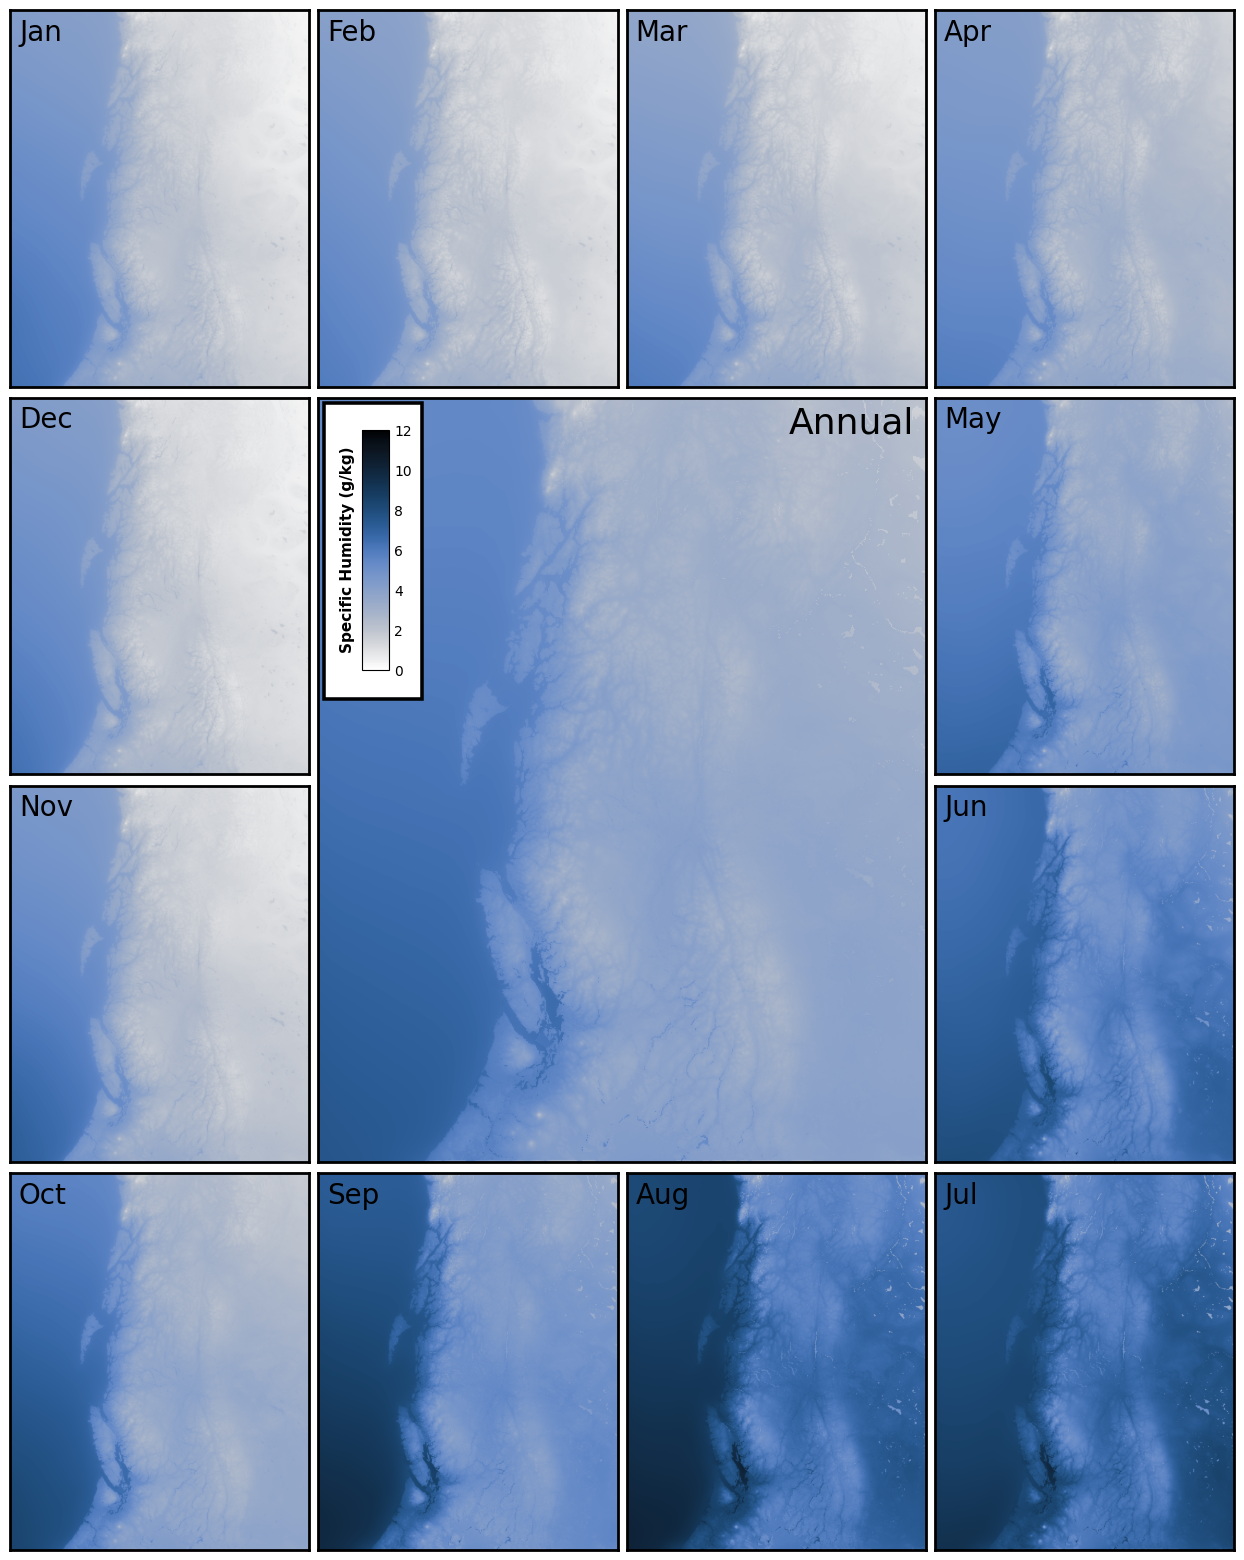

In [6]:
data = [q2_ymonmean_ds.isel(Times=i)['Q2'].values for i in range(12)] + [q2_yyearmean_ds['Q2'].values]
titles = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul',
          'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Annual']

# Set up figure and GridSpec layout
fig = plt.figure(figsize=(15.8, 20))
gs = gridspec.GridSpec(4, 4, figure=fig, wspace=0.03, hspace=0.03)

# Index map for where each panel goes (row, col)
positions = {
    'Jan':  (0, 0), 'Feb':  (0, 1), 'Mar':  (0, 2), 'Apr':  (0, 3),
    'May':  (1, 3), 'Jun':  (2, 3), 'Jul':  (3, 3), 'Aug':  (3, 2),
    'Sep':  (3, 1), 'Oct':  (3, 0), 'Nov':  (2, 0), 'Dec':  (1, 0),
    'Annual': (1, 1)  # Annual goes in the center and spans multiple rows/cols
}

# Add the plots
for i, name in enumerate(titles):
    if name == 'Annual':
        ax = fig.add_subplot(gs[1:3, 1:3])  # Larger annual plot
        ax.set_title(name, loc='right', fontsize=26, pad=-26, x=.98, y=1.000001)

        # white box on which the colorbar will be placed and its black border:
        ax.plot([50, 50],[470,652], linewidth=68, color='w', alpha=1.)
        ax.add_patch(Rectangle((6, 426), 88, 270, linewidth=4, edgecolor='black', facecolor='none', alpha=1.))

    else:
        row, col = positions[name]
        ax = fig.add_subplot(gs[row, col])
        ax.set_title(name, loc='left', fontsize=20, pad=-22, x=0.03, y=1.000001)

    im = ax.imshow(data[i], cmap=cm.oslo_r, vmin=0, vmax=12, origin='lower',)
    print(f'{name} Max:', np.nanmax(data[i]))

    ax.set_frame_on(True)
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('black')
        spine.set_linewidth(2)

# Add shared colorbar
cbar_ax = fig.add_axes([0.348, 0.550, 0.017, 0.12])  # [left, bottom, width, height]
fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cbar_ax.yaxis.set_label_position('left')
cbar_ax.set_ylabel('Specific Humidity (g/kg)', rotation=90, labelpad=5, fontsize=11, weight='bold')
cbar_ax.tick_params(axis='y', length=0)

# fig.savefig('/users/rpayne/ClimatExWRF/Robert/results/WRF_UBC_Q2_annualcycle.png', dpi=200, bbox_inches='tight')
plt.show()

# USask WRF

In [7]:
q2_usask_ymonmean_ds = xr.open_dataset("/users/rpayne/data/unproc/WRF-USASK/ctl/Q2/merged/Q2_ymonmean_regrid_200010_201508.nc")
q2_usask_ymonmean_ds = q2_usask_ymonmean_ds.assign_coords(time=np.arange(1, 13))
q2_usask_ymonmean_ds['Q2'] = 1e3*q2_usask_ymonmean_ds['Q2']  # convert to g/kg
q2_usask_yyearmean_ds = q2_usask_ymonmean_ds.mean(dim='time')

q2_usask_ymonmean_ds

<xarray.Dataset> Size: 22MB
Dimensions:  (south_north: 702, west_east: 558, time: 12)
Coordinates:
    XLONG    (south_north, west_east) float32 2MB ...
    XLAT     (south_north, west_east) float32 2MB ...
  * time     (time) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Dimensions without coordinates: south_north, west_east
Data variables:
    Q2       (time, south_north, west_east) float32 19MB nan nan ... 0.5834
Attributes: (12/81)
    CDI:                             Climate Data Interface version 1.9.9rc1 ...
    Conventions:                     CF-1.4
    history:                         Mon Sep 15 14:58:25 2025: cdo remapbil,/...
    TITLE:                            OUTPUT FROM WRF V3.6.1 MODEL
    START_DATE:                      2000-10-01_00:00:00
    WEST-EAST_GRID_DIMENSION:        640
    ...                              ...
    Division:                        GIWS, UofS
    Contacts:                        SOPAN KURKUTE (kurkute.sopan@usask.ca)
    nco_openmp_thread_number:        1
    NCO:                             4.6.6
    gwf_product:                     ctl-wrf-wca
    CDO:                             Climate Data Operators version 1.9.9rc1 ...

Jan Max: 6.2967463
Feb Max: 5.9090714
Mar Max: 5.9606643
Apr Max: 6.333187
May Max: 7.355127
Jun Max: 8.5528345
Jul Max: 10.449825
Aug Max: 10.501832
Sep Max: 9.58055
Oct Max: 8.2843
Nov Max: 7.0186677
Dec Max: 6.229787
Annual Max: 7.3903756


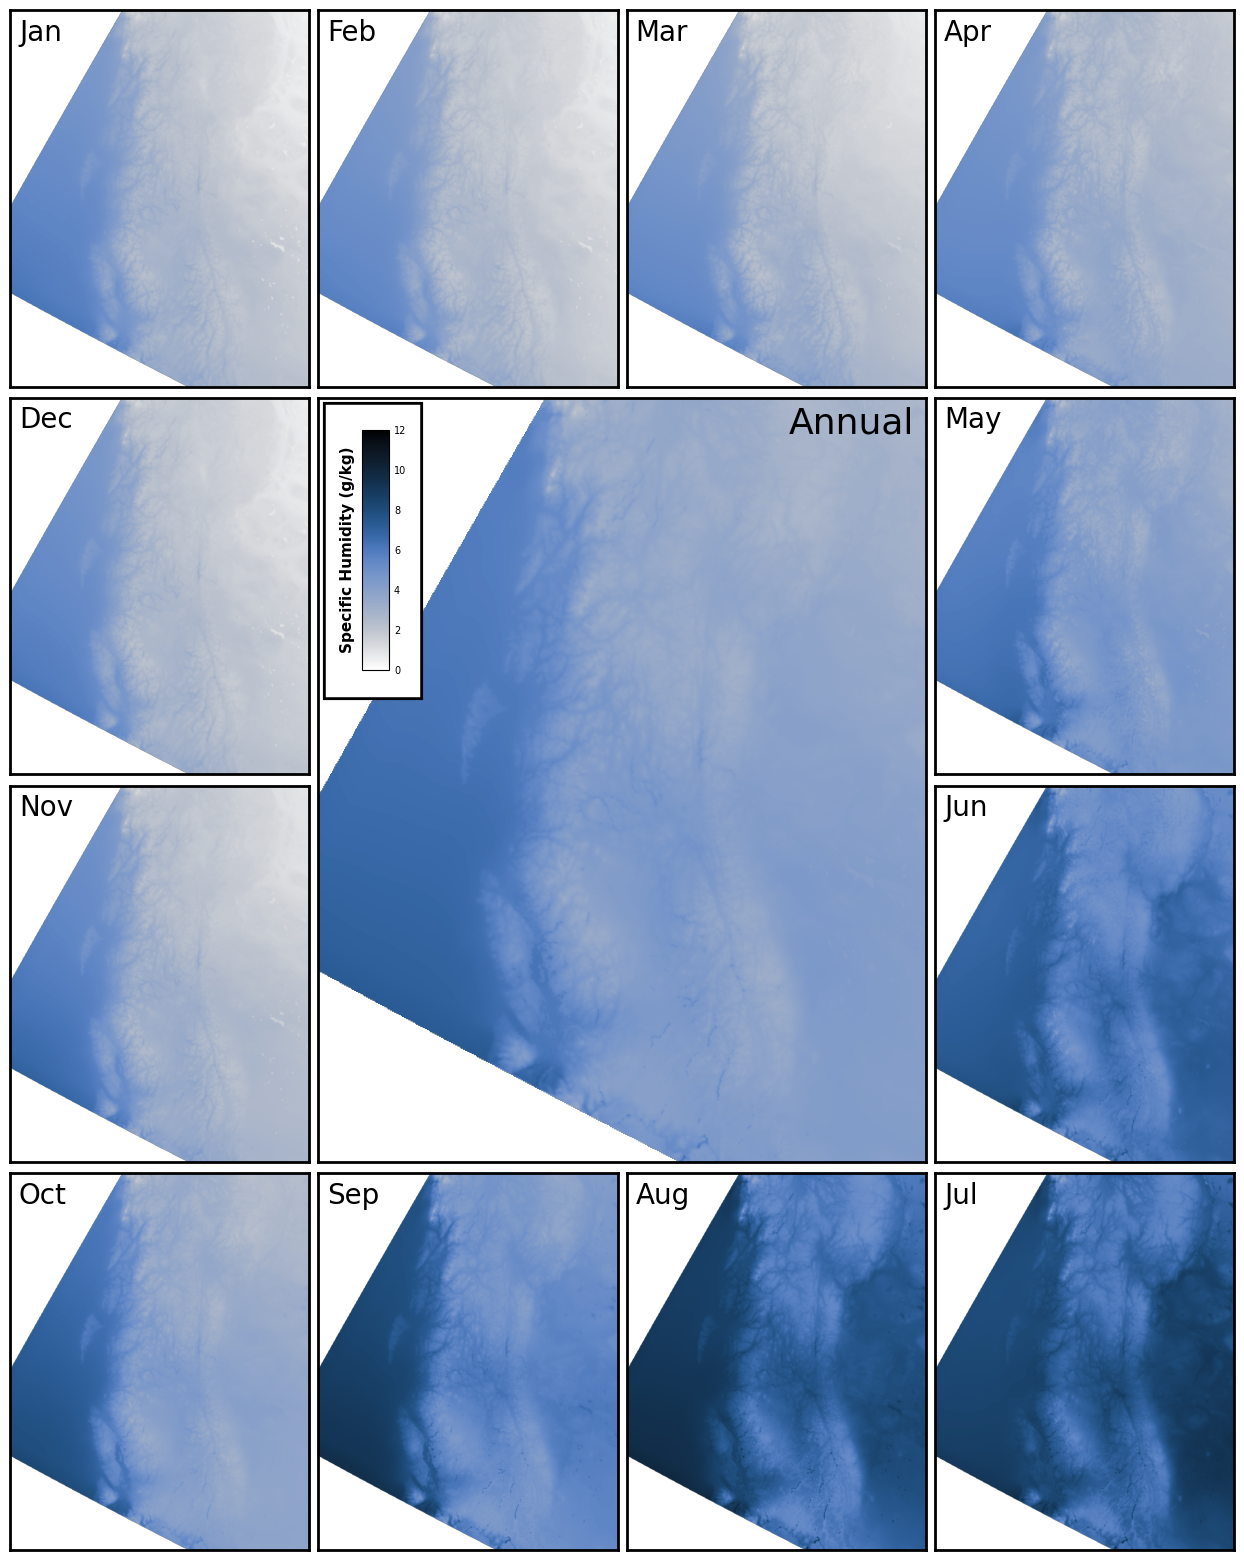

In [14]:
data = [q2_usask_ymonmean_ds.isel(time=i)['Q2'].values for i in range(12)] + [q2_usask_yyearmean_ds['Q2'].values]
titles = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul',
          'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Annual']

# Set up figure and GridSpec layout
fig = plt.figure(figsize=(15.8, 20))
gs = gridspec.GridSpec(4, 4, figure=fig, wspace=0.03, hspace=0.03)

# Index map for where each panel goes (row, col)
positions = {
    'Jan':  (0, 0), 'Feb':  (0, 1), 'Mar':  (0, 2), 'Apr':  (0, 3),
    'May':  (1, 3), 'Jun':  (2, 3), 'Jul':  (3, 3), 'Aug':  (3, 2),
    'Sep':  (3, 1), 'Oct':  (3, 0), 'Nov':  (2, 0), 'Dec':  (1, 0),
    'Annual': (1, 1)  # Annual goes in the center and spans multiple rows/cols
}

# Add the plots
for i, name in enumerate(titles):
    if name == 'Annual':
        ax = fig.add_subplot(gs[1:3, 1:3])  # Larger annual plot
        ax.set_title(name, loc='right', fontsize=26, pad=-26, x=.98, y=1.000001)

        # white box on which the colorbar will be placed and its black border:
        ax.plot([50, 50],[470,652], linewidth=68, color='w', alpha=1.)
        ax.add_patch(Rectangle((6, 426), 88, 270, linewidth=3, edgecolor='black', facecolor='none', alpha=1.))

    else:
        row, col = positions[name]
        ax = fig.add_subplot(gs[row, col])
        ax.set_title(name, loc='left', fontsize=20, pad=-22, x=0.03, y=1.000001)

    im = ax.imshow(data[i], cmap=cm.oslo_r, vmin=0, vmax=12, origin='lower',)
    print(f'{name} Max:', np.nanmax(data[i]))

    ax.set_frame_on(True)
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('black')
        spine.set_linewidth(2)

# Add shared colorbar
cbar_ax = fig.add_axes([0.348, 0.550, 0.017, 0.12])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cbar_ax.yaxis.set_label_position('left')
cbar_ax.set_ylabel('Specific Humidity (g/kg)', rotation=90, labelpad=5, fontsize=11, weight='bold')
cbar_ax.tick_params(axis='y', length=0, labelsize=7)
cbar.set_ticks(np.arange(0, 12 + 2, 2))

# fig.savefig('/users/rpayne/ClimatExWRF/Robert/results/WRF_USask_Q2_annualcycle.png', dpi=200, bbox_inches='tight')
plt.show()

Jan Min: -1.6782827377319336, Max: 1.1928887367248535
Feb Min: -1.6744911670684814, Max: 0.9535125494003296
Mar Min: -1.7880589962005615, Max: 0.7718825340270996
Apr Min: -1.8842833042144775, Max: 1.0127711296081543
May Min: -2.6839818954467773, Max: 1.673180103302002
Jun Min: -3.4691741466522217, Max: 2.082655906677246
Jul Min: -5.418463706970215, Max: 3.09297513961792
Aug Min: -5.114017486572266, Max: 2.8502979278564453
Sep Min: -4.122140884399414, Max: 2.0617752075195312
Oct Min: -2.27052640914917, Max: 1.1225275993347168
Nov Min: -1.991830587387085, Max: 0.9375181198120117
Dec Min: -1.7666246891021729, Max: 0.9621053338050842
Annual Min: -2.4458603858947754, Max: 1.1210432052612305


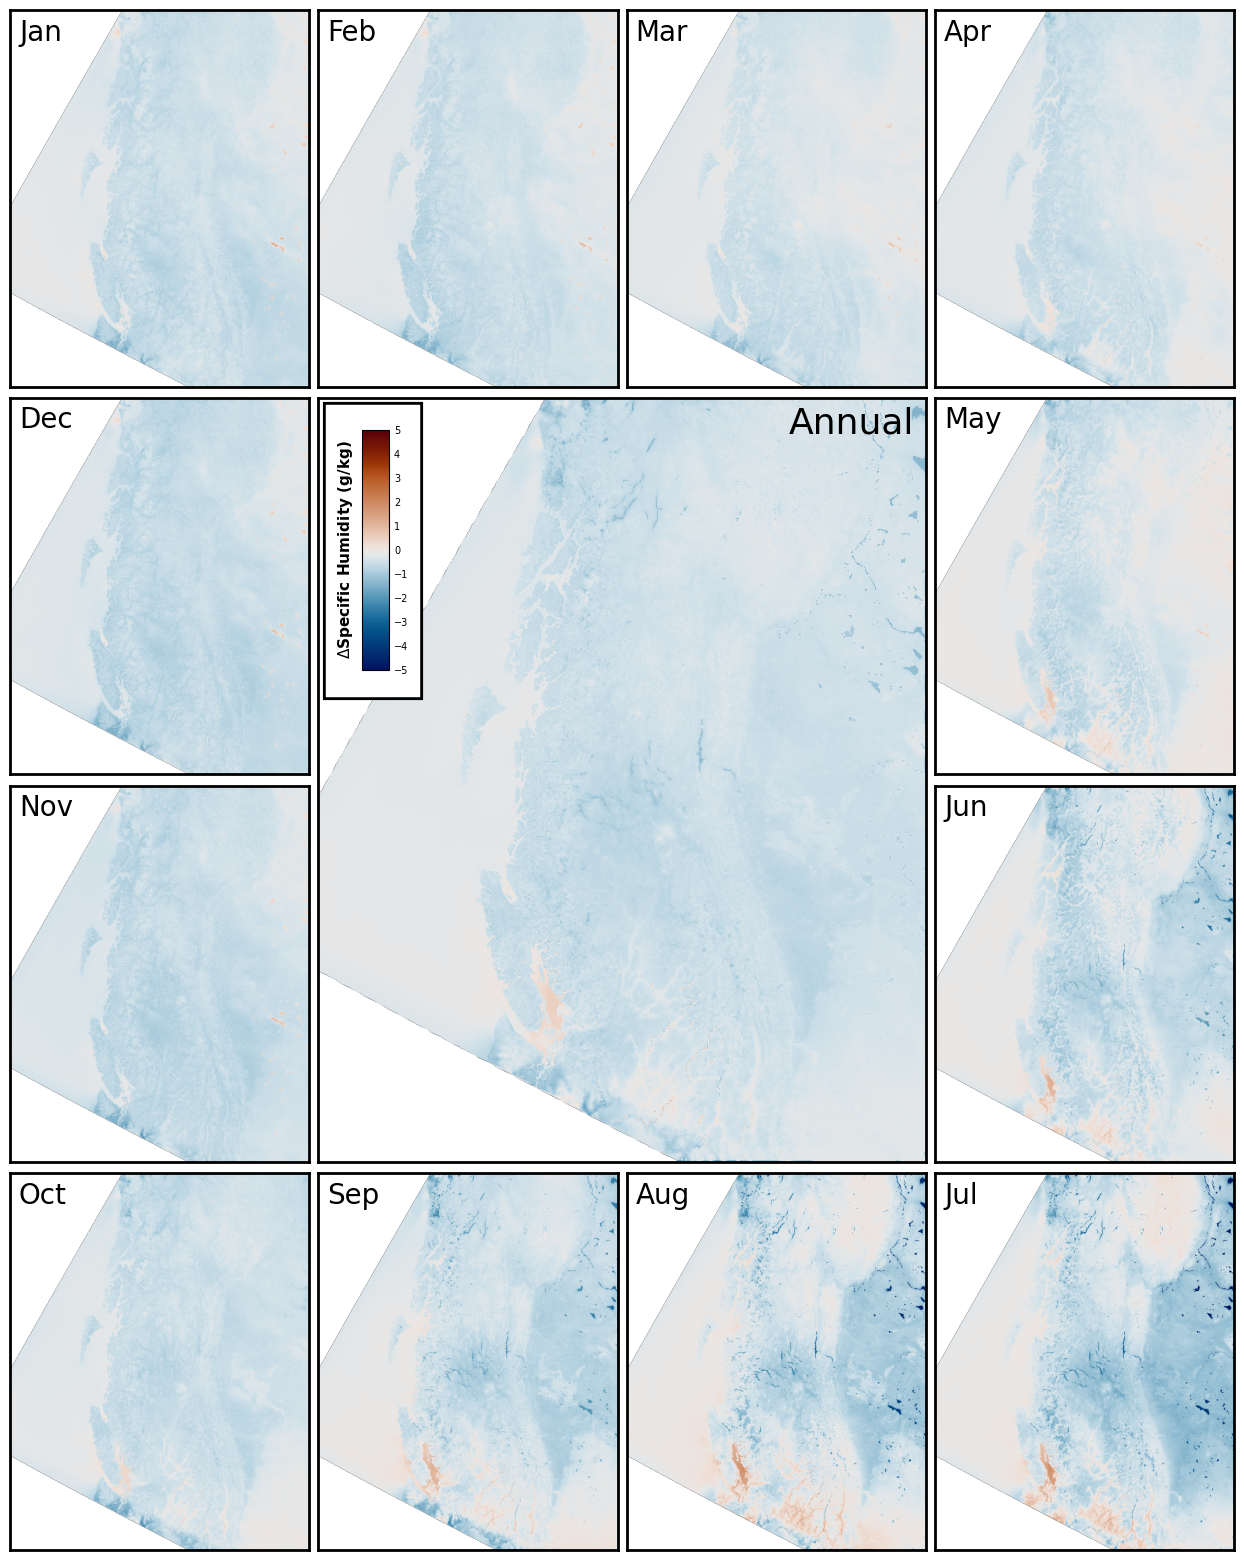

In [13]:
data = [q2_ymonmean_ds.isel(Times=i)['Q2'].values - q2_usask_ymonmean_ds.isel(time=i)['Q2'].values for i in range(12)] + [q2_yyearmean_ds['Q2'].values - q2_usask_yyearmean_ds['Q2'].values]
titles = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul',
          'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Annual']

# Set up figure and GridSpec layout
fig = plt.figure(figsize=(15.8, 20))
gs = gridspec.GridSpec(4, 4, figure=fig, wspace=0.03, hspace=0.03)

# Index map for where each panel goes (row, col)
positions = {
    'Jan':  (0, 0), 'Feb':  (0, 1), 'Mar':  (0, 2), 'Apr':  (0, 3),
    'May':  (1, 3), 'Jun':  (2, 3), 'Jul':  (3, 3), 'Aug':  (3, 2),
    'Sep':  (3, 1), 'Oct':  (3, 0), 'Nov':  (2, 0), 'Dec':  (1, 0),
    'Annual': (1, 1)  # Annual goes in the center and spans multiple rows/cols
}

# Add the plots
for i, name in enumerate(titles):
    if name == 'Annual':
        ax = fig.add_subplot(gs[1:3, 1:3])  # Larger annual plot
        ax.set_title(name, loc='right', fontsize=26, pad=-26, x=.98, y=1.000001)

        # white box on which the colorbar will be placed and its black border:
        ax.plot([50, 50],[470,652], linewidth=68, color='w', alpha=1.)
        ax.add_patch(Rectangle((6, 426), 88, 270, linewidth=3, edgecolor='black', facecolor='none', alpha=1.))

    else:
        row, col = positions[name]
        ax = fig.add_subplot(gs[row, col])
        ax.set_title(name, loc='left', fontsize=20, pad=-22, x=0.03, y=1.000001)

    im = ax.imshow(data[i], cmap=cm.vik, origin='lower', vmin= -5, vmax=5)
    print(f'{name} Min: {np.nanmin(data[i])}, Max: {np.nanmax(data[i])}')

    ax.set_frame_on(True)
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('black')
        spine.set_linewidth(2)

# Add shared colorbar
cbar_ax = fig.add_axes([0.348, 0.550, 0.017, 0.12])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cbar_ax.yaxis.set_label_position('left')
cbar_ax.set_ylabel('$\Delta$Specific Humidity (g/kg)', rotation=90, labelpad=5, fontsize=11, weight='bold')
cbar_ax.tick_params(axis='y', length=0., labelsize=7)
cbar.set_ticks(np.arange(-5, 5 + 1, 1))

plt.show()